# 06 · Test design: sizing the retargeting and Display holdouts

Two recommendations rest on effects that this observational data can't measure:

- **D2, retargeting** ([notebook 04](04_analyze_remarketing.ipynb)): the break-even borrows a **10% lift** from published experiments. Only a randomized holdout can measure this store's own lift.
- **D1, Display** ([notebook 05](05_analyze_attribution.ipynb)): attribution can't show whether Display *causes* the purchases GA credits to it.

This notebook sizes both tests from the store's own volumes before anyone runs them: how large an effect each design can detect, and how long it has to run.

**Method** ([`src/power.py`](../src/power.py)): normal approximation, two-sided test at α = 5% with 80% power, so z\* = z₀.₉₇₅ + z₀.₈₀ = 2.80.

- **Per-visitor metrics** (a 30-day purchase or return visit, revenue): with n visitors, a share h held out and a per-visitor standard deviation σ (σ = √(p(1 − p)) for a rate p), the difference between the arms has SE = σ·√(1/((1 − h)n) + 1/(hn)). The smallest relative lift detected with 80% power is **MDE = 2.80 · SE / μ**, and the power at a lift L is Φ(Lμ/SE − 1.96) + Φ(−Lμ/SE − 1.96). σ is the holdout's, used for both arms, which is slightly optimistic: the standard unpooled two-proportion test gives slightly larger MDEs, about 14.4% rather than 14.0% for purchases at 12 months.
- **Weekly counts** (Display): if every Display-credited purchase were incremental, the holdout would lose D of the store's S purchases a week. Over W weeks the full-scale difference between the arms has variance W · (S/(1 − h) + (S − D)/h) under a Poisson model. Visitors who come back repeatedly add noise, which a variance-inflation factor (VIF) allows for.
- **Duration:** the shortest enrollment at which power reaches 80%.

**Assumptions:** visitors are independent and the arms don't affect each other; the test months' rates (May 1 – Jul 1, 2017) hold; the analysis is intention to treat (everyone assigned to retargeting counts, whether an ad reached them or not; if only a share r is reached, the lift detectable among them is MDE ÷ r); results are read 30 days after enrollment closes; the break-even compares a purchase lift with a revenue threshold, so the extra buyers are assumed to spend like the average buyer (a check at readout: revenue per buyer by arm).

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from src import viz
from src.breakeven import CENTRAL, REVENUE_CAP_USD, breakeven_lift, months_spanned, value_of_targets
from src.modeling import LABEL, PIPELINES, add_features
from src.power import (duration_for_power, poisson_mde, poisson_power, proportion_sd, two_sample_mde,
                       two_sample_power, z_star)
from src.segments import is_key_account
from src.tables import remarketing_table

# scikit-learn warns when the test months contain categories unseen in training (handled as "infrequent")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

LIFT = 0.10   # the lift notebook 04's break-even assumes
DURATIONS = {"6_weeks": 42 / 30.4, "3_months": 3.0, "6_months": 6.0, "12_months": 12.0}   # months of enrollment
sessions = pd.read_parquet(ROOT / "data/raw/sessions_clean.parquet")
print(f"z* = {z_star():.4f}")

z* = 2.8016


## 1. Retargeting holdout (D2)

**Who is randomized:** first-time visitors who score into the audience, assigned when they're scored and before any ad is served. The inputs therefore come from the population a live campaign would score (notebook 04, section 9): the table without hindsight, with the chosen model refit on it. Staff, the Google employees whom only a later visit reveals, can't be removed at scoring time. They can be left out of the analysis, though. Staff are identified by internal-link visits, mostly after assignment, so the exclusion uses post-treatment data: ads can't create those visits but could replace some of them. Staff are only 2.4% of the top 20%, so the bias should be small. At readout, check that the share identified as staff is balanced across the arms, and also report the result with staff included.

In [2]:
live = add_features(remarketing_table(sessions, internal_flag="first_visit"))
train, test = live[live.split == "train"], live[live.split == "test"]
tuning = pd.read_json(ROOT / "data/processed/tuning_results.json")
chosen = tuning.loc[tuning.cv_pr_auc.idxmax()]   # notebook 04's model: the best validation PR-AUC (gradient boosting)
score = PIPELINES[chosen.model](**chosen.params).fit(train, train[LABEL]).predict_proba(test)[:, 1]
months = months_spanned(test.session_date)   # May 1 – Jul 1, 2017: 62 days, both ends included
order = np.argsort(-score, kind="stable")

rows = []
for frac in (0.10, 0.20):
    audience = test.iloc[order[: int(round(frac * len(test)))]]
    analysed = audience[~audience.is_internal]   # staff are dropped at analysis
    revenue = np.minimum(analysed.revenue_30d_usd, REVENUE_CAP_USD)
    rows.append({"audience": f"top {frac:.0%}", "visitors_per_month": len(audience) / months,
                 "staff_share": audience.is_internal.mean(), "analysed_per_month": len(analysed) / months,
                 "purchase_rate": analysed[LABEL].mean(), "return_visit_rate": (analysed.return_visits_30d > 0).mean(),
                 "revenue_per_visitor": revenue.mean(), "revenue_sd": revenue.std()})
inputs = pd.DataFrame(rows).set_index("audience")
inputs.style.format({"visitors_per_month": "{:,.0f}", "staff_share": "{:.1%}", "analysed_per_month": "{:,.0f}",
                     "purchase_rate": "{:.2%}", "return_visit_rate": "{:.1%}", "revenue_per_visitor": "${:.2f}",
                     "revenue_sd": "${:.2f}"})

,visitors_per_month,staff_share,analysed_per_month,purchase_rate,return_visit_rate,revenue_per_visitor,revenue_sd
audience,,,,,,,
top 10%,"4,510",3.7%,"4,343",2.57%,22.7%,$3.43,$41.49
top 20%,"9,019",2.4%,"8,803",1.50%,18.9%,$2.15,$36.90


In [3]:
# Later buyers in the top 20%. Staff are identified by internal-link visits, mostly after assignment, so an ad that
# replaced those visits could leave a staff buyer counted as a real one. Spend per real buyer is also skewed.
from src.tables import WINDOW_DAYS

audience20 = test.iloc[order[: int(round(0.20 * len(test)))]]
buyers20 = audience20[audience20[LABEL].eq(1)]
real_buyers = buyers20[~buyers20.is_internal]
staff_buyers = buyers20.loc[buyers20.is_internal, ["full_visitor_id", "first_start"]]
links = sessions.loc[sessions.is_internal_entry.astype(bool), ["full_visitor_id", "visit_start_time", "purchased"]] \
    .merge(staff_buyers, on="full_visitor_id")   # every internal-link visit of a staff buyer
links["in_window"] = links.visit_start_time.gt(links.first_start) & \
    links.visit_start_time.le(links.first_start + WINDOW_DAYS * 86400)
per_staff = links.assign(link_buy=links.purchased.astype(bool) & links.in_window).groupby("full_visitor_id") \
    .agg(link_buy=("link_buy", "any"), all_in_window=("in_window", "all"))
link_buyers = int(per_staff.link_buy.sum())
hideable = int((~per_staff.link_buy & per_staff.all_in_window).sum())
print(f"Top 20%: {len(staff_buyers)} staff later buyers, {link_buyers} of whom bought through the internal link within "
      f"{WINDOW_DAYS} days and {len(staff_buyers) - link_buyers} did not; {len(real_buyers)} real later buyers")
print(f"Bound on the staff bias in the relative purchase lift = staff buyers an ad could hide (no purchase through the "
      f"link, every internal-link visit inside the {WINDOW_DAYS}-day window: {hideable}) / real later buyers = "
      f"{hideable / len(real_buyers):.0%} ({hideable / len(real_buyers):.2%}). Looser, counting every staff buyer who "
      f"didn't buy through the link: {(len(staff_buyers) - link_buyers) / len(real_buyers):.1%} "
      f"({(len(staff_buyers) - link_buyers) / len(real_buyers):.2%})")
spend = np.minimum(real_buyers.revenue_30d_usd, REVENUE_CAP_USD)
print(f"Capped 30-day spend per real later buyer ({len(spend)}): mean ${spend.mean():.0f} ({spend.mean():.2f}), "
      f"median ${spend.median():.0f} ({spend.median():.2f})")

Top 20%: 81 staff later buyers, 67 of whom bought through the internal link within 30 days and 14 did not; 270 real later buyers
Bound on the staff bias in the relative purchase lift = staff buyers an ad could hide (no purchase through the link, every internal-link visit inside the 30-day window: 8) / real later buyers = 3% (2.96%). Looser, counting every staff buyer who didn't buy through the link: 5.2% (5.19%)
Capped 30-day spend per real later buyer (270): mean $143 (143.23), median $62 (62.28)


The design randomizes the **top 20%**. Its purchase rate is lower than the top 10%'s (1.50% against 2.57%), but it doubles enrollment and brings about a fifth more buyers a month, so it detects smaller lifts (the line under the table compares them). Three candidate metrics, each measured per assigned visitor over the 30 days after assignment, under two splits: the 10% holdout first proposed (10/90) and an even split (50/50). The table gives the power to detect a +10% lift after 6 weeks to 12 months of enrollment, the smallest lift detectable at 12 months, and the enrollment needed for 80% power at +10%.

In [4]:
top20 = inputs.loc["top 20%"]
per_month = top20.analysed_per_month
metrics = {"30-day purchase rate": (top20.purchase_rate, proportion_sd(top20.purchase_rate)),
           "30-day return-visit rate": (top20.return_visit_rate, proportion_sd(top20.return_visit_rate)),
           "capped 30-day revenue": (top20.revenue_per_visitor, top20.revenue_sd)}
rows = []
for metric, (mean, sd) in metrics.items():
    for split, holdout in [("50/50", 0.5), ("10/90", 0.1)]:
        row = {"metric": metric, "split": split}
        for name, m in DURATIONS.items():
            row[f"power_{name}"] = two_sample_power(mean, sd, LIFT, per_month * m, holdout)
        row["mde_12_months"] = two_sample_mde(mean, sd, per_month * 12, holdout)
        row["months_for_80pct"] = duration_for_power(lambda m: two_sample_power(mean, sd, LIFT, per_month * m, holdout))
        rows.append(row)
retargeting = pd.DataFrame(rows).set_index(["metric", "split"])
top10 = inputs.loc["top 10%"]
print(f"Top 20%: {per_month * top20.purchase_rate:.0f} later buyers a month analyzed. Top 10% instead: "
      f"{top10.analysed_per_month * top10.purchase_rate:.0f} a month, and a 12-month 50/50 MDE for purchases of "
      f"{two_sample_mde(top10.purchase_rate, proportion_sd(top10.purchase_rate), top10.analysed_per_month * 12, 0.5):.1%}")
retargeting.style.format({**{c: "{:.0%}" for c in retargeting.columns if c.startswith("power")},
                          "mde_12_months": "{:.1%}", "months_for_80pct": "{:,.1f}"})

Top 20%: 132 later buyers a month analyzed. Top 10% instead: 112 a month, and a 12-month 50/50 MDE for purchases of 15.1%


In [5]:
# Two checks on the 12-month 50/50 purchase MDE: the standard unpooled two-proportion test (each arm its own
# variance), and the first version's divisor of 61 days ((last date - first date).days) instead of 62.
from scipy.optimize import brentq
from scipy.stats import norm

p = top20.purchase_rate
unpooled_se = lambda lift, n: np.sqrt(p * (1 - p) / (0.5 * n) + p * (1 + lift) * (1 - p * (1 + lift)) / (0.5 * n))
unpooled_power = lambda lift, n: (norm.cdf(lift * p / unpooled_se(lift, n) - norm.ppf(0.975))
                                  + norm.cdf(-lift * p / unpooled_se(lift, n) - norm.ppf(0.975)))
unpooled_mde = brentq(lambda lift: lift * p - z_star() * unpooled_se(lift, per_month * 12), 1e-6, 10)
unpooled_power_12 = unpooled_power(LIFT, per_month * 12)
unpooled_months = duration_for_power(lambda m: unpooled_power(LIFT, per_month * m))
table = retargeting.loc[("30-day purchase rate", "50/50")]
print(f"Unpooled test: 12-month MDE {unpooled_mde:.1%} ({unpooled_mde:.2%}), power at +10% after 12 months "
      f"{unpooled_power_12:.0%} ({unpooled_power_12:.2%}), {unpooled_months:.1f} months to 80% ({unpooled_months:.2f})")
print(f"Holdout's variance for both arms (the table): 12-month MDE {table.mde_12_months:.1%} ({table.mde_12_months:.2%}), "
      f"power at +10% after 12 months {table.power_12_months:.0%} ({table.power_12_months:.2%}), "
      f"{table.months_for_80pct:.1f} months to 80% ({table.months_for_80pct:.2f})")
months_61 = (test.session_date.max() - test.session_date.min()).days / 30.4
old_mde = two_sample_mde(p, proportion_sd(p), top20.analysed_per_month * months / months_61 * 12, 0.5)
print(f"First version's 61-day divisor: 12-month MDE {old_mde:.1%} ({old_mde:.2%}), against {table.mde_12_months:.1%} "
      f"({table.mde_12_months:.2%}) with 62 days")

Unpooled test: 12-month MDE 14.4% (14.44%), power at +10% after 12 months 50% (50.02%), 24.5 months to 80% (24.51)
Holdout's variance for both arms (the table): 12-month MDE 14.0% (13.95%), power at +10% after 12 months 52% (51.92%), 23.4 months to 80% (23.36)
First version's 61-day divisor: 12-month MDE 13.8% (13.84%), against 14.0% (13.95%) with 62 days


In [6]:
# The lift a test must detect for retargeting to pay: cost per retargeted visitor / (revenue per visitor x margin).
# Staff are valued at $0: they cost money to reach, but an ad can't make them buy.
revenue_per_visitor = value_of_targets(test[LABEL].to_numpy(), test.revenue_30d_usd.to_numpy(), score, months,
                                       targets=(0.20,), zero_lift=test.is_internal.to_numpy()).revenue_per_visitor[0]
mde = retargeting.loc[("30-day purchase rate", "50/50"), "mde_12_months"]
print(f"Top 20%: capped 30-day revenue ${revenue_per_visitor:.2f} per retargeted visitor (staff at $0). The 12-month "
      f"MDE ({mde:.1%}) is the break-even lift at ${mde * revenue_per_visitor * CENTRAL['margin']:.3f} per retargeted visitor.")
costs = [0.05, 0.10, 0.15, 0.20]
pd.DataFrame({"cost_per_retargeted_visitor": costs, "breakeven_lift": breakeven_lift(costs, revenue_per_visitor)}) \
    .style.format({"cost_per_retargeted_visitor": "${:.2f}", "breakeven_lift": "{:.1%}"}).hide(axis="index")

Top 20%: capped 30-day revenue $2.10 per retargeted visitor (staff at $0). The 12-month MDE (14.0%) is the break-even lift at $0.147 per retargeted visitor.


cost_per_retargeted_visitor,breakeven_lift
$0.05,4.8%
$0.10,9.5%
$0.15,14.3%
$0.20,19.0%


In [7]:
# Two unadjusted 95% reads, after 12 and 24 months of enrollment, when the true lift equals break-even. The second read
# includes the first read's data, so the two z-statistics correlate at sqrt(12 / 24).
from scipy.integrate import quad

z_a, rho = norm.ppf(0.975), np.sqrt(12 / 24)
both_inside = quad(lambda x: norm.pdf(x) * (norm.cdf((z_a - rho * x) / np.sqrt(1 - rho ** 2))
                                            - norm.cdf((-z_a - rho * x) / np.sqrt(1 - rho ** 2))), -z_a, z_a)[0]
wrong_call = 1 - both_inside
print(f"Chance of a wrong keep or stop call at break-even with two unadjusted reads: {wrong_call:.0%} ({wrong_call:.2%}); "
      f"{wrong_call / 2:.0%} in each direction ({wrong_call / 2:.2%}); one read: {2 * norm.sf(z_a):.0%}")

Chance of a wrong keep or stop call at break-even with two unadjusted reads: 8% (8.31%); 4% in each direction (4.16%); one read: 5%


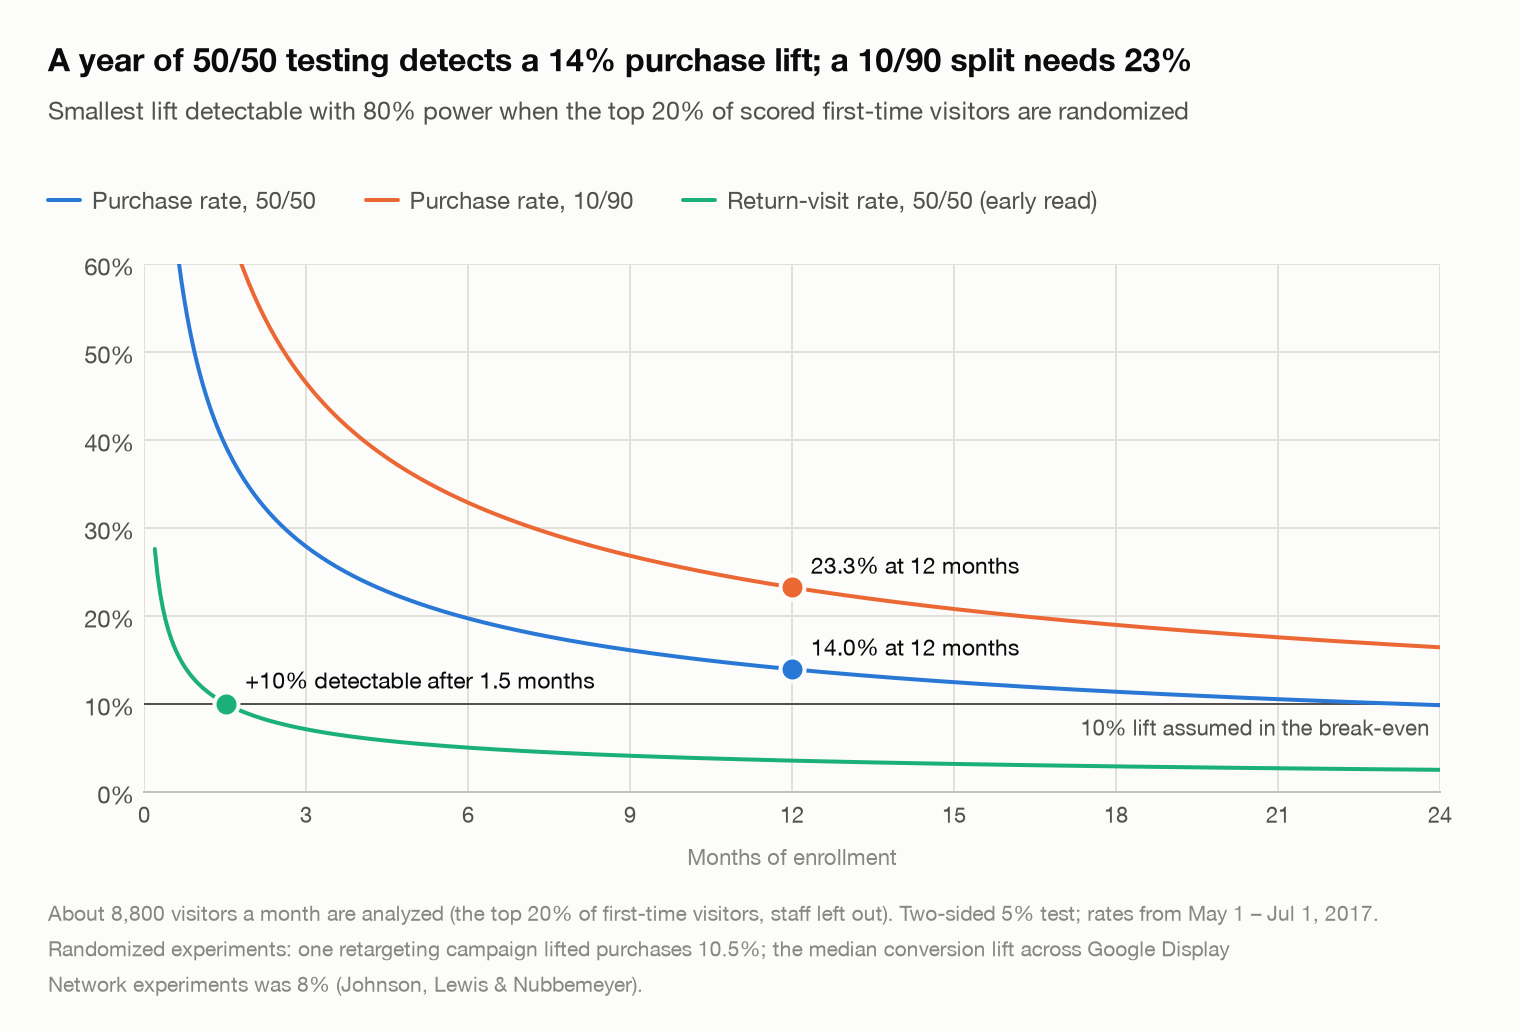

In [8]:
# Smallest detectable lift by months of enrollment (no viz helper draws this form, so it's drawn here in the same style)
m_axis = np.linspace(0.2, 24, 480)
p, r = top20.purchase_rate, top20.return_visit_rate
curves = {"Purchase rate, 50/50": (two_sample_mde(p, proportion_sd(p), per_month * m_axis, 0.5), viz.SERIES_1),
          "Purchase rate, 10/90": (two_sample_mde(p, proportion_sd(p), per_month * m_axis, 0.1), "#eb6834"),
          "Return-visit rate, 50/50 (early read)": (two_sample_mde(r, proportion_sd(r), per_month * m_axis, 0.5), "#1baf7a")}
at_12 = {split: two_sample_mde(p, proportion_sd(p), per_month * 12, h) for split, h in [("50/50", 0.5), ("10/90", 0.1)]}
early = duration_for_power(lambda m: two_sample_power(r, proportion_sd(r), LIFT, per_month * m, 0.5))

viz.apply_style()
fig, ax = viz.figure(760, 516, plot_box=(72, 132, 40, 120))   # 3-line footnote
ax.set_xlim(0, 24)
ax.set_ylim(0, 0.6)
ax.set_xticks(range(0, 25, 3), [str(m) for m in range(0, 25, 3)])
ax.set_yticks(np.arange(0, 0.61, 0.1), [f"{t:.0%}" for t in np.arange(0, 0.61, 0.1)])
ax.grid(axis="both", zorder=0)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(viz.AXIS)
ax.set_xlabel("Months of enrollment", fontsize=viz.px(11), color=viz.MUTED, labelpad=6)
ax.axhline(LIFT, color=viz.INK_2, lw=viz.px(1), zorder=2)
ax.text(23.8, LIFT - 0.012, "10% lift assumed in the break-even", ha="right", va="top", fontsize=viz.px(11),
        color=viz.INK_2)
for label, (mde_curve, color) in curves.items():
    ax.plot(m_axis, mde_curve, color=color, lw=viz.px(2), solid_capstyle="round", solid_joinstyle="round", zorder=3)
for split, color in [("50/50", viz.SERIES_1), ("10/90", "#eb6834")]:
    viz.dot(ax, 12, at_12[split], color, diameter_px=8)
    ax.text(12.35, at_12[split] + 0.01, f"{at_12[split]:.1%} at 12 months", ha="left", va="bottom",
            fontsize=viz.px(11.5), color=viz.INK)
viz.dot(ax, early, LIFT, "#1baf7a", diameter_px=8)
ax.text(early + 0.35, LIFT + 0.012, f"+10% detectable after {early:.1f} months", ha="left", va="bottom",
        fontsize=viz.px(11.5), color=viz.INK)

viz.header(fig, f"A year of 50/50 testing detects a {at_12['50/50']:.0%} purchase lift; a 10/90 split needs "
                f"{at_12['10/90']:.0%}",
           "Smallest lift detectable with 80% power when the top 20% of scored first-time visitors are randomized")
w, h = fig.get_size_inches() * viz.PX_PER_IN
lx = 24
for label, (_, color) in curves.items():   # legend row under the subtitle
    fig.add_artist(Line2D([lx / w, (lx + 16) / w], [1 - 100 / h] * 2, color=color, lw=viz.px(2),
                          transform=fig.transFigure, solid_capstyle="round"))
    t = fig.text((lx + 22) / w, 1 - 100 / h, label, ha="left", va="center", fontsize=viz.px(12), color=viz.INK_2)
    fig.canvas.draw()
    lx += 22 + t.get_window_extent().width / (fig.dpi / viz.PX_PER_IN) + 26
viz.footnote(fig, f"About {round(per_month, -2):,.0f} visitors a month are analyzed (the top 20% of first-time visitors, staff left out). "
                  "Two-sided 5% test; rates from May 1 – Jul 1, 2017.\nRandomized experiments: one retargeting campaign lifted purchases "
                  "10.5%; the median conversion lift across Google Display\nNetwork experiments was 8% (Johnson, Lewis & "
                  "Nubbemeyer).")
viz.show_saved(fig, ROOT / "reports/figures/test_retargeting_mde.png")

In [9]:
ret_6_weeks = retargeting.loc[("30-day return-visit rate", "50/50"), "power_6_weeks"]
print(f"Early read: +10% in return visits (50/50) reaches 80% power after {early:.1f} months of enrollment "
      f"({early:.3f}), that is {early * 30.4:.0f} days ({early * 30.4:.1f}) or {early * 30.4 / 7:.1f} weeks; power after "
      f"6 weeks: {ret_6_weeks:.0%} ({ret_6_weeks:.2%})")
print(f"With the {WINDOW_DAYS}-day follow-up, the early read is available {early + WINDOW_DAYS / 30.4:.1f} months after "
      f"launch ({early + WINDOW_DAYS / 30.4:.2f}, {early * 30.4 + WINDOW_DAYS:.0f} days)")

Early read: +10% in return visits (50/50) reaches 80% power after 1.5 months of enrollment (1.525), that is 46 days (46.4) or 6.6 weeks; power after 6 weeks: 76% (76.00%)
With the 30-day follow-up, the early read is available 2.5 months after launch (2.51, 76 days)


**Retargeting:**

- **A 10% holdout is badly underpowered.** At a +10% lift, a 10/90 split has 7% power after 6 weeks, 9% after 3 months, 14% after 6 months and 23% after 12 months. It would need about 5 years (65 months) to reach 80%.
- **Purchases need a 50/50 split and a year.** Twelve months of enrollment detect a lift of about 14% (14.0%) with 80% power. A +10% lift has only 52% power and would take about 23 months. A 14.0% lift is also the break-even lift at USD 0.147 per retargeted visitor (per visitor assigned to retargeting, so reach is already included). That is power against no effect, not against break-even. If retargeting does nothing, a year shows it doesn't pay with at least 80% probability whenever the real cost is at or above USD 0.147. But if the true lift is near break-even (for example the assumed 10% at a cost of USD 0.10, where break-even is 9.5%), the 95% CI will usually straddle break-even and the test won't decide. The second read at the end of an extension (the rule allows one, up to 24 months) isn't adjusted, so the chance of a wrong keep or stop call at break-even is about 8%, not 5%.
- **Return visits give an early read.** A +10% lift in the 30-day return-visit rate is detectable after about 1.5 months at 50/50 (4 months at 10/90). That shows the ads reach people; it doesn't show they cause purchases.
- **Revenue can't be the metric.** Capped 30-day revenue is so skewed that a 12-month 50/50 test detects only lifts of about 30% or more; +10% would take more than 8 years (105 months).

## 2. Display holdout (D1)

The question is whether Display ads cause the purchases GA credits to them. Volumes come from 52 complete weeks of outside sessions (Aug 1, 2016 – Jul 30, 2017): purchases and visits GA labels **Display**, and the subset that are **fresh ad clicks** rather than return visits carrying Display's tag (`isTrueDirect`).

**The key account is left out** of both the store-wide and the Display volumes. Visitor 1957458976293878100 is now reported as its own segment (`src/segments.py`). Its purchases come from an existing corporate relationship, which a holdout of ad audiences wouldn't move, and it alone would add 15 GA-labeled Display purchases, all on return visits.

In [10]:
START = pd.Timestamp("2016-08-01")   # a Monday: 52 complete weeks to 2017-07-30
sessions = sessions.assign(week=(sessions.session_date - START).dt.days // 7)
key = sessions[is_key_account(sessions.full_visitor_id) & sessions.week.between(0, 51)]
key_display = key[key.channel.eq("Display")]
print(f"Left out, the key account: {len(key):,} visits and {int(key.purchased.sum())} purchases, of which "
      f"{int(key_display.purchased.sum())} GA-labeled Display ({int(key_display[key_display.is_true_direct.astype(bool)].purchased.sum())} "
      "on return visits)")
outside = sessions[~sessions.is_internal.astype(bool) & ~is_key_account(sessions.full_visitor_id)].query("0 <= week <= 51")
ga_label = outside.channel.eq("Display")
fresh = ga_label & ~outside.is_true_direct.astype(bool)
weekly = pd.DataFrame({
    ("purchases", "store-wide"): outside.groupby("week").purchased.sum(),
    ("purchases", "Display, GA label"): outside[ga_label].groupby("week").purchased.sum(),
    ("purchases", "Display, fresh ad clicks"): outside[fresh].groupby("week").purchased.sum(),
    ("sessions", "store-wide"): outside.groupby("week").size(),
    ("sessions", "Display, GA label"): outside[ga_label].groupby("week").size(),
    ("sessions", "Display, fresh ad clicks"): outside[fresh].groupby("week").size(),
}).reindex(range(52)).fillna(0)   # a week without any Display visit or purchase counts as zero
per_week = weekly.mean()

# Visitors who come back repeatedly make weekly counts noisier than Poisson. Variance-inflation factor per visitor,
# over the last 12 complete weeks: sum(c^2) / sum(c), where c is each visitor's count (1 for a pure Poisson process).
recent = outside[outside.week >= 40]
vif = {"purchases": (recent.groupby("full_visitor_id").purchased.sum() ** 2).sum() / recent.purchased.sum(),
       "sessions": (recent.groupby("full_visitor_id").size() ** 2).sum() / len(recent)}
print(f"variance inflation from repeat visitors: purchases {vif['purchases']:.2f}, sessions {vif['sessions']:.2f}")
pd.DataFrame({"per_week": per_week, "total_52_weeks": weekly.sum()}).style.format(
    {"per_week": "{:,.2f}", "total_52_weeks": "{:,.0f}"})

Left out, the key account: 275 visits and 16 purchases, of which 15 GA-labeled Display (15 on return visits)


variance inflation from repeat visitors: purchases 1.21, sessions 2.05


In [11]:
# Power to detect the loss if EVERY Display-credited purchase (or visit) were incremental: the largest effect possible
rows = []
for outcome in ["purchases", "sessions"]:
    store = per_week[(outcome, "store-wide")]
    for credited in ["Display, GA label", "Display, fresh ad clicks"]:
        lost = per_week[(outcome, credited)]
        for holdout in (0.10, 0.20, 0.50):
            row = {"outcome": outcome, "credited": credited, "holdout": f"{holdout:.0%}", "per_week": lost,
                   "share_of_store": lost / store}
            for weeks in (4, 6, 12):
                row[f"power_{weeks}_weeks"] = poisson_power(store, store - lost, weeks, holdout)
            row["power_12_weeks_with_repeats"] = poisson_power(store, store - lost, 12, holdout, vif=vif[outcome])
            row["weeks_for_80pct_with_repeats"] = duration_for_power(
                lambda w: poisson_power(store, store - lost, w, holdout, vif=vif[outcome]))
            rows.append(row)
display_power = pd.DataFrame(rows).set_index(["outcome", "credited", "holdout"])
display_power.style.format({"per_week": "{:,.2f}", "share_of_store": "{:.2%}", "power_4_weeks": "{:.1%}",
                            "power_6_weeks": "{:.1%}", "power_12_weeks": "{:.1%}", "power_12_weeks_with_repeats": "{:.1%}",
                            "weeks_for_80pct_with_repeats": "{:,.0f}"})

In [12]:
# The site-visit test, 50/50 for 12 weeks: store-wide MDE, and the largest randomized audience (visits a week) at which
# losing all Display-credited visits is detected with 80% power. Solves D W = z* sqrt(vif 2 W (2 S - D)) for S.
weeks, store = 12, per_week[("sessions", "store-wide")]
rows = []
for credited in ["Display, GA label", "Display, fresh ad clicks"]:
    lost = per_week[("sessions", credited)]
    for variance, v in [("Poisson", 1.0), ("with repeat visitors", vif["sessions"])]:
        largest = (lost ** 2 * weeks / (2 * z_star() ** 2 * v) + lost) / 2
        rows.append({"credited": credited, "variance": variance, "lost_per_week": lost,
                     "store_wide_power": poisson_power(store, store - lost, weeks, 0.5, vif=v),
                     "store_wide_mde_per_week": poisson_mde(store, weeks, 0.5, vif=v),
                     "largest_audience_per_week": largest, "largest_share_of_outside_visits": largest / store,
                     "power_at_largest": poisson_power(largest, largest - lost, weeks, 0.5, vif=v)})
visits_test = pd.DataFrame(rows).set_index(["credited", "variance"])
visits_test.style.format({"lost_per_week": "{:,.1f}", "store_wide_power": "{:.1%}", "store_wide_mde_per_week": "{:,.0f}",
                          "largest_audience_per_week": "{:,.0f}", "largest_share_of_outside_visits": "{:.1%}",
                          "power_at_largest": "{:.1%}"})

In [13]:
# The limits above assume the audience repeats like average outside traffic. For candidate audiences (their visits in
# weeks 40-51): the VIF, the largest randomized audience (both arms together) with 80% power to detect the loss of all
# Display-credited visits, the held-out half's visits at that size, and the power there if only half are incremental.
vif_of = lambda visits: (visits.groupby("full_visitor_id").size() ** 2).sum() / len(visits)
display_ids = recent.loc[recent.channel.eq("Display"), "full_visitor_id"].unique()
fixed_list = outside.loc[outside.week < 40, "full_visitor_id"].unique()
audiences = {"all outside traffic": recent,
             "Display's own visitors": recent[recent.full_visitor_id.isin(display_ids)],
             "past visitors (returning visits)": recent[recent.visit_number > 1],
             "a list fixed before week 40": recent[recent.full_visitor_id.isin(fixed_list)]}
limits = {}
for audience, visits in audiences.items():
    v = vif_of(visits)
    print(f"{audience}: VIF {v:.2f} ({v:.4f})")
    for credited in ["Display, GA label", "Display, fresh ad clicks"]:
        lost = per_week[("sessions", credited)]
        largest = (lost ** 2 * weeks / (2 * z_star() ** 2 * v) + lost) / 2
        held_out = 0.5 * (largest - lost)
        limits[(audience, credited)] = largest
        half_power = poisson_power(largest, largest - lost / 2, weeks, 0.5, vif=v)
        print(f"  {credited}: 80% power up to {largest:,.0f} visits a week for the whole randomized audience, both arms "
              f"({largest:,.1f}); the held-out half then makes {held_out:,.0f} ({held_out:,.1f}); power if half the "
              f"credited visits are incremental: {half_power:.0%} ({half_power:.2%})")

all outside traffic: VIF 2.05 (2.0539)
  Display, GA label: 80% power up to 2,044 visits a week for the whole randomized audience, both arms (2,043.7); the held-out half then makes 970 (970.1); power if half the credited visits are incremental: 29% (28.54%)
  Display, fresh ad clicks: 80% power up to 1,184 visits a week for the whole randomized audience, both arms (1,183.7); the held-out half then makes 553 (552.6); power if half the credited visits are incremental: 28% (28.44%)
Display's own visitors: VIF 4.52 (4.5175)
  Display, GA label: 80% power up to 957 visits a week for the whole randomized audience, both arms (957.4); the held-out half then makes 427 (427.0); power if half the credited visits are incremental: 28% (28.18%)
  Display, fresh ad clicks: 80% power up to 560 visits a week for the whole randomized audience, both arms (559.6); the held-out half then makes 241 (240.6); power if half the credited visits are incremental: 28% (27.98%)
past visitors (returning visits): VIF

**Display:**

- **A purchase-based holdout can't work at this store's volume.** Without the key account, Display is credited with 2.15 purchases a week (1.27 from fresh ad clicks) out of 117 store-wide. Even if every one were incremental, a 10%, 20% or 50% holdout run for 4 to 12 weeks has 5.1–6.4% power, barely above the 5% that chance alone gives. Reaching 80% would take at least 18 years (952 weeks, allowing for repeat buyers).
- **Site visits are the measurable outcome.** Display is credited with 103 visits a week (78 of them fresh ad clicks). A 50/50 split for 12 weeks detects the loss of all 103 with 30% power store-wide, or 17% allowing for repeat visitors. It reaches 80% power only if the randomized audience is small. An audience that repeats like average outside traffic (VIF 2.05) could make up to about 2,000 visits a week (13% of outside traffic; about 4,100 under a pure Poisson model). But the audience to test, Display's own visitors, repeats more (VIF about 4.5), so the limit falls to about 960 visits a week, or about 560 counting only fresh ad clicks: about 500–1,000 visits a week. Every Display-credited visit is also assumed incremental: at half that effect, power at the limit falls to about 29%.

## 3. Recommended designs

In [14]:
p50 = retargeting.loc[("30-day purchase rate", "50/50")]
ret50 = retargeting.loc[("30-day return-visit rate", "50/50")]
ga = visits_test.loc[("Display, GA label", "with repeat visitors")]
display_limit = limits[("Display's own visitors", "Display, GA label")]  # cell above
designs = pd.DataFrame({
    "Retargeting (D2)": {
        "Randomize": "First-time visitors scored into the top 20%, by visitor ID, at scoring time (before any ad)",
        "Primary metric": ("30-day purchase rate per assigned visitor (intention to treat), with staff identified "
                           "afterwards left out. Early read: 30-day return-visit rate"),
        "Split": "50/50 (retargeted / held out)",
        "Duration": "12 months of enrollment, read 30 days after it closes",
        "MDE (80% power)": (f"{p50.mde_12_months:.1%} relative lift in purchases ({p50.power_12_months:.0%} power at +10%); "
                            f"+10% in return visits after {ret50.months_for_80pct:.1f} months"),
        "Decision rule": (f"Break-even lift = cost per retargeted visitor ÷ (${revenue_per_visitor:.2f} × 50% margin). "
                          "Before reading the lift, check that the share of enrollees identified as staff is balanced "
                          "across arms (two-proportion test, same detection window for every enrollee), and also report "
                          "the result with staff included. Keep retargeting if the purchase lift's 95% CI lies above the "
                          "break-even lift and stop if it lies below it; this assumes the extra buyers spend like the "
                          "average buyer, so check revenue per buyer by arm. Otherwise extend enrollment once, up to 24 "
                          "months, and decide then, on the point estimate if the CI still straddles break-even "
                          f"(about {p50.months_for_80pct:.0f} months gives 80% power to detect +10% against no effect, "
                          "not against break-even, so a lift close to break-even may never be resolved). "
                          "Early read: if return visits aren't clearly up, fix ad delivery before waiting a year. "
                          "After the decision, keep a 10% holdout to monitor"),
    },
    "Display (D1)": {
        "Randomize": "Users in the audiences Display campaigns target, split by the ad platform per user (not by region)",
        "Primary metric": ("Site visits per assigned user, by any route. Purchases and revenue reported but not "
                           "powered"),
        "Split": "50/50 (shown ads / held out)",
        "Duration": "12 weeks",
        "MDE (80% power)": (f"The loss of all {ga.lost_per_week:.0f} Display-credited visits a week, if the audience makes "
                            f"at most {display_limit:,.0f} visits a week, "
                            f"repeating like Display's own visitors ({ga.largest_audience_per_week:,.0f} if it repeats like "
                            f"average outside traffic; store-wide power {ga.store_wide_power:.0%})"),
        "Decision rule": ("If held-out users make significantly fewer visits, Display adds traffic: value the extra "
                          "visits at the store's revenue per visit and compare with Display's cost. If the difference's "
                          "95% CI stays below the visits GA credits to Display, GA over-credits it: budget Display on "
                          "the measured difference, not on GA's report"),
    },
})
designs.style.set_properties(**{"text-align": "left", "white-space": "normal"})

,Retargeting (D2),Display (D1)
Randomize,"First-time visitors scored into the top 20%, by visitor ID, at scoring time (before any ad)","Users in the audiences Display campaigns target, split by the ad platform per user (not by region)"
Primary metric,"30-day purchase rate per assigned visitor (intention to treat), with staff identified afterwards left out. Early read: 30-day return-visit rate","Site visits per assigned user, by any route. Purchases and revenue reported but not powered"
Split,50/50 (retargeted / held out),50/50 (shown ads / held out)
Duration,"12 months of enrollment, read 30 days after it closes",12 weeks
MDE (80% power),14.0% relative lift in purchases (52% power at +10%); +10% in return visits after 1.5 months,"The loss of all 103 Display-credited visits a week, if the audience makes at most 957 visits a week, repeating like Display's own visitors (2,044 if it repeats like average outside traffic; store-wide power 17%)"
Decision rule,"Break-even lift = cost per retargeted visitor ÷ ($2.10 × 50% margin). Before reading the lift, check that the share of enrollees identified as staff is balanced across arms (two-proportion test, same detection window for every enrollee), and also report the result with staff included. Keep retargeting if the purchase lift's 95% CI lies above the break-even lift and stop if it lies below it; this assumes the extra buyers spend like the average buyer, so check revenue per buyer by arm. Otherwise extend enrollment once, up to 24 months, and decide then, on the point estimate if the CI still straddles break-even (about 23 months gives 80% power to detect +10% against no effect, not against break-even, so a lift close to break-even may never be resolved). Early read: if return visits aren't clearly up, fix ad delivery before waiting a year. After the decision, keep a 10% holdout to monitor","If held-out users make significantly fewer visits, Display adds traffic: value the extra visits at the store's revenue per visit and compare with Display's cost. If the difference's 95% CI stays below the visits GA credits to Display, GA over-credits it: budget Display on the measured difference, not on GA's report"
